In [1]:
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
import os
import pandas as pd
import numpy as np

In [2]:
TRAIN_DIR = 'images/train'
TEST_DIR = 'images/test'

In [3]:
def createdataframe(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
            image_paths.append(os.path.join(dir,label,imagename))
            labels.append(label)
        print(label, "completed")
    return image_paths,labels

In [4]:
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(TRAIN_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [5]:
print(train)

                                             image     label
0               images/train\angry\angry_00000.jpg     angry
1               images/train\angry\angry_00001.jpg     angry
2               images/train\angry\angry_00002.jpg     angry
3               images/train\angry\angry_00003.jpg     angry
4               images/train\angry\angry_00004.jpg     angry
...                                            ...       ...
49774  images/train\surprise\surprise_aug01776.jpg  surprise
49775  images/train\surprise\surprise_aug01777.jpg  surprise
49776  images/train\surprise\surprise_aug01778.jpg  surprise
49777  images/train\surprise\surprise_aug01779.jpg  surprise
49778  images/train\surprise\surprise_aug01780.jpg  surprise

[49779 rows x 2 columns]


In [6]:
test = pd.DataFrame()
test['image'], test['label'] = createdataframe(TEST_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [7]:
print(test)
print(test['image'])

                                            image     label
0               images/test\angry\angry_00000.jpg     angry
1               images/test\angry\angry_00001.jpg     angry
2               images/test\angry\angry_00002.jpg     angry
3               images/test\angry\angry_00003.jpg     angry
4               images/test\angry\angry_00004.jpg     angry
...                                           ...       ...
49774  images/test\surprise\surprise_aug01776.jpg  surprise
49775  images/test\surprise\surprise_aug01777.jpg  surprise
49776  images/test\surprise\surprise_aug01778.jpg  surprise
49777  images/test\surprise\surprise_aug01779.jpg  surprise
49778  images/test\surprise\surprise_aug01780.jpg  surprise

[49779 rows x 2 columns]
0                 images/test\angry\angry_00000.jpg
1                 images/test\angry\angry_00001.jpg
2                 images/test\angry\angry_00002.jpg
3                 images/test\angry\angry_00003.jpg
4                 images/test\angry\angry_0000

In [8]:
from tqdm.notebook import tqdm

In [9]:
def extract_features(images):
    features = []

    for image in tqdm(images):
        img = load_img(image, color_mode='grayscale', target_size=(48,48))
        img = np.array(img)
        features.append(img)

    features = np.array(features)
    features = features.reshape(len(features),48,48,1)

    return features

In [10]:
from tqdm import tqdm
import numpy as np
from tensorflow.keras.preprocessing.image import load_img

def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode='grayscale')
        img = np.array(img)
        features.append(img)

    features = np.array(features)
    features = features.reshape(len(features), 48,48, 1)
    return features

In [11]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

TRAIN_DIR = 'images/train'
TEST_DIR = 'images/test'


# Create dataframe
def createdataframe(dir):
    image_paths = []
    labels = []

    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir, label)):
            image_paths.append(os.path.join(dir, label, imagename))
            labels.append(label)

        print(label, "completed")

    return image_paths, labels


# Train dataframe
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(TRAIN_DIR)

print(train.head())


# Test dataframe
test = pd.DataFrame()
test['image'], test['label'] = createdataframe(TEST_DIR)

print(test.head())


# Feature extraction
def extract_features(images):
    features = []

    for image in tqdm(images):
        img = load_img(image, color_mode='grayscale', target_size=(48,48))
        img = np.array(img)
        features.append(img)

    features = np.array(features)
    features = features.reshape(len(features), 48, 48, 1)

    return features


# Extract train features
train_features = extract_features(train['image'])
test_features = extract_features(test['image'])

print("Feature shape:", train_features.shape)
print("Test feature shape:", test_features.shape)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed
                                image  label
0  images/train\angry\angry_00000.jpg  angry
1  images/train\angry\angry_00001.jpg  angry
2  images/train\angry\angry_00002.jpg  angry
3  images/train\angry\angry_00003.jpg  angry
4  images/train\angry\angry_00004.jpg  angry
angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed
                               image  label
0  images/test\angry\angry_00000.jpg  angry
1  images/test\angry\angry_00001.jpg  angry
2  images/test\angry\angry_00002.jpg  angry
3  images/test\angry\angry_00003.jpg  angry
4  images/test\angry\angry_00004.jpg  angry


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49779/49779 [10:31<00:00, 78.87it/s]


Feature shape: (49779, 48, 48, 1)
Test feature shape: (49779, 48, 48, 1)


In [13]:
x_train = train_features/255.0
x_test = test_features/255.0


In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
from sklearn.preprocessing import LabelEncoder

# Example usage
le = LabelEncoder()
y_train = le.fit_transform(train['label'])
y_test = le.transform(test['label'])

# If you want one-hot encoding for CNN
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (49779, 7)
y_test shape: (49779, 7)


In [16]:
le = LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [17]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [18]:
y_train = to_categorical(y_train,num_classes = 7)
y_test = to_categorical(y_test,num_classes = 7)

In [19]:
model = Sequential()
# convolutional layers
model.add(Conv2D(128, kernel_size=(3,3), activation='relu', input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())
# fully connected layers
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
# output layer
model.add(Dense(7, activation='softmax'))

C:\Users\asree\Downloads\face_emotion_detection\venv310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_classes = 7  # replace with your number of emotion classes

model = Sequential()
model.add(Input(shape=(48,48,1)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# ✅ Correct compilation
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

print("Model compiled successfully!")

Model compiled successfully!


In [31]:
model.fit(x= x_train,y = y_train, batch_size = 128, epochs =100, validation_data = (x_test,y_test))

Epoch 1/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 57s 144ms/step - accuracy: 0.6476 - loss: 0.9055 - val_accuracy: 0.7321 - val_loss: 0.7149
Epoch 2/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.6523 - loss: 0.8881 - val_accuracy: 0.7421 - val_loss: 0.7055
Epoch 3/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 54s 139ms/step - accuracy: 0.6632 - loss: 0.8651 - val_accuracy: 0.7604 - val_loss: 0.6458
Epoch 4/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 76s 123ms/step - accuracy: 0.6648 - loss: 0.8592 - val_accuracy: 0.7685 - val_loss: 0.6541
Epoch 5/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 55s 142ms/step - accuracy: 0.6664 - loss: 0.8408 - val_accuracy: 0.7747 - val_loss: 0.6236
Epoch 6/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 52s 134ms/step - accuracy: 0.6739 - loss: 0.8317 - val_accuracy: 0.7839 - val_loss: 0.6104
Epoch 7/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 54s 139ms/step - accuracy: 0.6783 - loss: 0.8167 - val_accuracy: 0.7891 - val_loss: 0.5890
Epoch 8/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 53s 136ms/step - accuracy: 0.6790 -

In [32]:
model_json = model.to_json()
with open("emotiondetector.json",'w') as json_file:
    json_file.write(model_json)
model.save("emotiondetector.h5")


In [33]:
from keras.models import model_from_json

In [34]:
model_json = model.to_json()
with open("facialemotionmodel.json",'w') as json_file:
    json_file.write(model_json)
model.save("facialemotionmodel.h5")

In [35]:
label = ['angry','disgust','fear','happy','neutral','sad','surprise']

In [36]:
from tensorflow.keras.preprocessing.image import load_img
import numpy as np

def ef(image):
    img = load_img(image, color_mode='grayscale', target_size=(48,48))
    feature = np.array(img)
    feature = feature.reshape(1,48,48,1)
    return feature/255.0

In [37]:
image = 'images/train/sad/sad_00000.jpg'
print("original image is of sad")

img = ef(image)

pred = model.predict(img)
pred_label = label[pred.argmax()]

print("model prediction is", pred_label)

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
model prediction is sad


In [38]:
pip install matplotlib


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import matplotlib.pyplot as plt
%matplotlib inline

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
model prediction is  sad


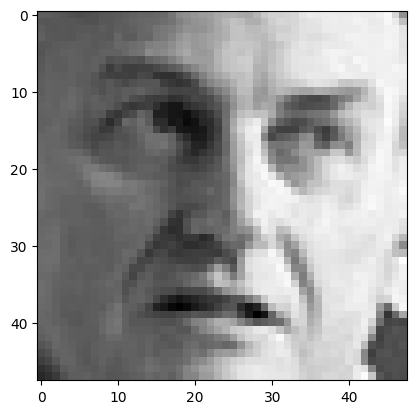

In [40]:
image = 'images/train/sad/sad_00000.jpg'
print("original image is of sad")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')